# MultiOutputKriging on a curve-valued simulator (R)

A simulator often returns a **curve** per run rather than a single number. Here each run returns the damped
oscillation

$$y(x, t) = e^{-a(x)\,t} \cos\!\left(\frac{2\pi f(x)\, t}{5}\right),\qquad f = 0.5 + x_1,\quad a = 0.1 + 0.5\,x_2,$$

sampled at $q = 50$ time steps, for two inputs $x \in [0, 1]^2$. `MultiOutputKriging` fits the $q$ outputs at once:
`Y` is an $n \times q$ matrix (one row per run, one column per time step), with the same rows as `X`.

Four output models are compared (see [docs/math/MultiOutput.md](../../docs/math/MultiOutput.md)):

- **`"pca"`**: Karhunen-Loève reduction of the curves, one `Kriging` per principal score (Higdon et al. 2008);
- **`"shared"`**: one correlation length vector θ for all outputs, outputs independent given θ (parallel partial
  GP, Gu & Berger 2016);
- **`"separable"`**: a free $q \times q$ output covariance Σ (intrinsic coregionalization model), here on 3 outputs;
- **`"separable(matern5_2)"`**: Σ = σ² R_t(φ), a Matérn 5/2 kernel over the time steps, on the 50 outputs.

Steps:
1. Setup
2. Simulator and design ($n = 60$ runs)
3. `"pca"`: fit, predicted curves, accuracy and coverage
4. `"shared"`: one θ for the 50 outputs
5. Baseline: one independent `Kriging` per output
6. `"separable"`: joint covariance between outputs
7. `"separable(matern5_2)"`: a kernel over the time steps
8. `update` and `update_simulate`: new runs without refitting
9. `save` and `load`
10. Summary

## 0. Installation (run once)

Install rlibkriging from CRAN (`install.packages("rlibkriging")`), or build it from source: the cell below runs
`tools/r-linux-macos/build.sh`, which builds the C++ core and installs **rlibkriging** into `bindings/R/Rlibs`.

In [1]:
# Run this cell once to build and install rlibkriging.
# Skip if already built (bindings/R/Rlibs/rlibkriging exists).
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
rlibs     <- file.path(repo_root, "bindings", "R", "Rlibs", "rlibkriging")

if (!dir.exists(rlibs)) {
  message("Building rlibkriging from source…")
  ret <- system(paste0("cd '", repo_root, "' && bash tools/r-linux-macos/build.sh"))
  if (ret != 0) stop("Build failed — check compiler and cmake installation.")
} else {
  message("rlibkriging already built, skipping.")
}

rlibkriging already built, skipping.



## 1. Load rlibkriging

In [2]:
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
lib_path  <- file.path(repo_root, "bindings", "R", "Rlibs")
suppressPackageStartupMessages(library(rlibkriging, lib.loc = lib_path))
options(repr.plot.width = 12, repr.plot.height = 4)

## 2. Simulator and design

$n = 60$ runs on a random design, and 200 test runs to measure the accuracy.

X: 60 2  Y: 60 50 


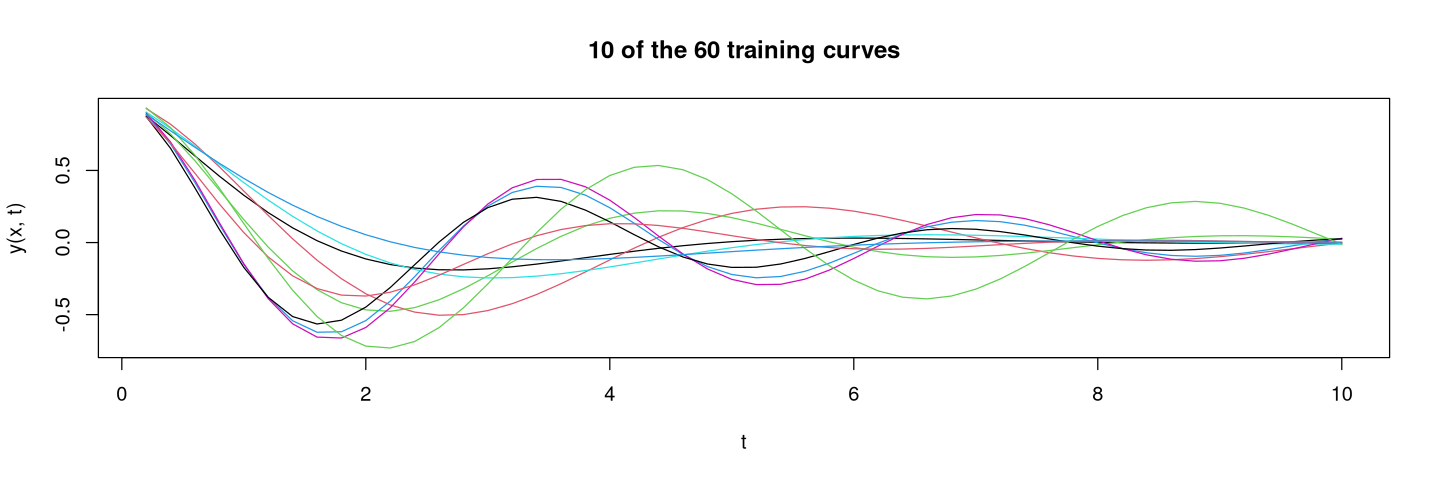

In [3]:
t <- seq(0.2, 10, length.out = 50)               # q = 50 time steps

simulator <- function(X) {
  f <- 0.5 + X[, 1]
  a <- 0.1 + 0.5 * X[, 2]
  exp(-outer(a, t)) * cos(2 * pi * outer(f, t) / 5)   # n x q
}

set.seed(1)
X <- matrix(runif(2 * 60), ncol = 2)
Y <- simulator(X)
Xt <- matrix(runif(2 * 200), ncol = 2)
Yt <- simulator(Xt)
cat("X:", dim(X), " Y:", dim(Y), "\n")

matplot(t, t(Y[1:10, ]), type = "l", lty = 1, xlab = "t", ylab = "y(x, t)",
        main = "10 of the 60 training curves")

## 3. `"pca"` output model

`"pca(0.999)"` keeps the principal components that explain 99.9 % of the variance of the centered curves, and fits
one `Kriging` per component score. The truncation residual is kept as white noise, so the predicted standard
deviation does not ignore the discarded components.

In [4]:
t_pca <- system.time(
  pca <- MultiOutputKriging(Y, X, kernel = "matern5_2", output_model = "pca(0.999)")
)["elapsed"]
print(pca)
cat("components:", pca$nb_components(), " cumulative explained variance:", round(pca$pca_explained(), 4), "\n")

* MultiOutputKriging, output model: pca(0.999)
  * covariance kernel: matern5_2
  * data: 60 x 2 -> 60 x 50
  * trend: constant
  * PCA components: 7, explained variance: 0.999319
    - component 0: cum. explained 0.558778, sigma2 3.09908, theta    0.7078   1.6318
    - component 1: cum. explained 0.840863, sigma2 2.306, theta    0.4672   1.0905
    - component 2: cum. explained 0.939402, sigma2 0.899079, theta    0.3024   0.7193
    - component 3: cum. explained 0.974132, sigma2 0.690421, theta    0.3507   0.9835
    - component 4: cum. explained 0.990727, sigma2 0.141548, theta    0.2132   0.6418
    - component 5: cum. explained 0.997959, sigma2 0.155256, theta    0.2537   0.7559
    - component 6: cum. explained 0.999319, sigma2 0.0264243, theta    0.2375   0.6574


components: 7  cumulative explained variance: 0.5588 0.8409 0.9394 0.9741 0.9907 0.998 0.9993 


In [5]:
scores <- function(mean, stdev) {
  c(rmse = sqrt(mean((mean - Yt)^2)) / sd(as.vector(Yt)),
    coverage = mean(abs(mean - Yt) <= 1.96 * stdev))
}

p <- predict(pca, Xt)
cat("mean, stdev:", dim(p$mean), "/", dim(p$stdev), "\n")
r_pca <- scores(p$mean, p$stdev)
cat(sprintf("pca: RMSE / sd(Y) = %.4f, coverage of the 95%% intervals = %.3f\n", r_pca[1], r_pca[2]))

mean, stdev: 200 50 / 200 50 


pca: RMSE / sd(Y) = 0.0560, coverage of the 95% intervals = 0.948


Predicted curves at three test inputs: predicted mean (solid), 95 % band (mean ± 1.96 stdev, shaded) and true
curve (dashed).

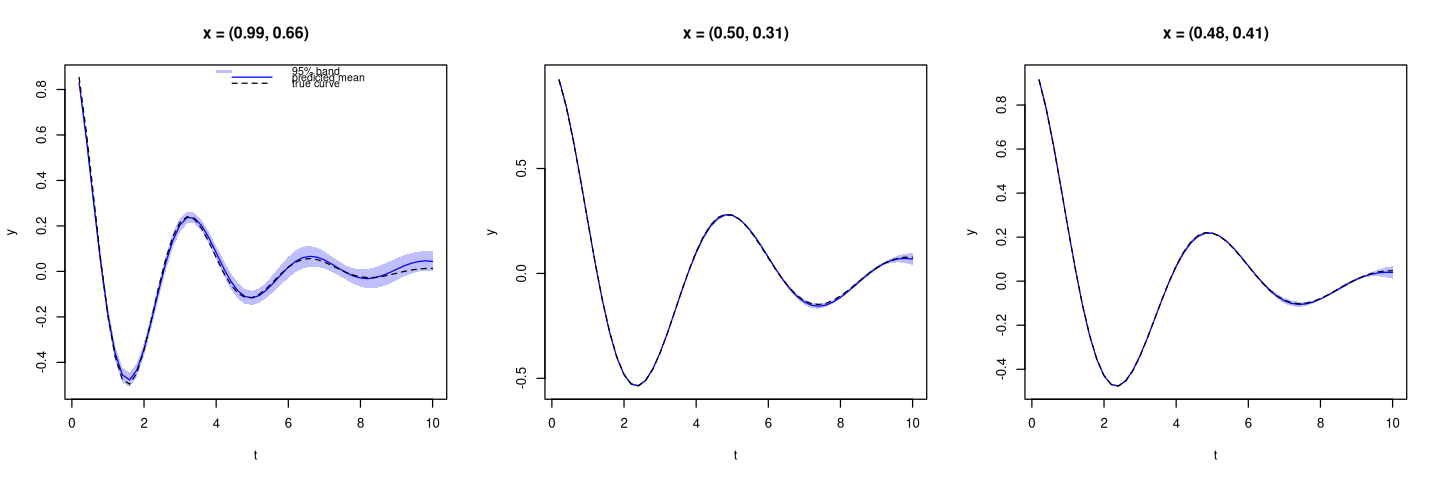

In [6]:
par(mfrow = c(1, 3))
for (i in 1:3) {
  lo <- p$mean[i, ] - 1.96 * p$stdev[i, ]
  hi <- p$mean[i, ] + 1.96 * p$stdev[i, ]
  plot(t, Yt[i, ], type = "n", ylim = range(lo, hi, Yt[i, ]), xlab = "t", ylab = "y",
       main = sprintf("x = (%.2f, %.2f)", Xt[i, 1], Xt[i, 2]))
  polygon(c(t, rev(t)), c(lo, rev(hi)), border = NA, col = rgb(0, 0, 1, 0.25))
  lines(t, p$mean[i, ], col = "blue")
  lines(t, Yt[i, ], lty = 2)
  if (i == 1) legend("topright", c("95% band", "predicted mean", "true curve"),
                     fill = c(rgb(0, 0, 1, 0.25), NA, NA), border = NA,
                     lty = c(NA, 1, 2), col = c(NA, "blue", "black"), cex = 0.8, bty = "n")
}
par(mfrow = c(1, 1))

## 4. `"shared"` output model

One θ for all 50 outputs, maximizing the summed concentrated log-likelihood: each likelihood evaluation costs
**one** Cholesky factorization for the 50 outputs. Each output keeps its own trend β_j and variance σ_j².

In [7]:
t_shared <- system.time(
  shared <- MultiOutputKriging(Y, X, kernel = "matern5_2", output_model = "shared")
)["elapsed"]
cat("theta:", theta(shared), "\n")
ps <- predict(shared, Xt)
r_shared <- scores(ps$mean, ps$stdev)
cat(sprintf("shared: RMSE / sd(Y) = %.4f, coverage = %.3f\n", r_shared[1], r_shared[2]))

theta: 0.7275767 1.65639 


shared: RMSE / sd(Y) = 0.0462, coverage = 0.949


## 5. Baseline: one independent `Kriging` per output

50 separate fits, each with its own θ. This remains a valid baseline: each time step gets the θ that suits it,
which can be slightly more accurate or not, depending on the design. The cost is 50 optimizations instead of one (`"shared"`) or a
handful (`"pca"`), no information shared between time steps, and no joint covariance between outputs.

In [8]:
t_indep <- system.time(
  models <- lapply(1:ncol(Y), function(j) Kriging(Y[, j], X, kernel = "matern5_2"))
)["elapsed"]
pi_ <- lapply(models, function(k) predict(k, Xt))
r_indep <- scores(sapply(pi_, function(q) q$mean), sapply(pi_, function(q) q$stdev))
cat(sprintf("independent: RMSE / sd(Y) = %.4f, coverage = %.3f\n", r_indep[1], r_indep[2]))

independent: RMSE / sd(Y) = 0.0496, coverage = 0.948


## 6. `"separable"` output model: joint covariance

`"separable"` estimates a free output covariance Σ (here between 3 close time steps, $t \approx 4.2, 4.6, 5.0$,
which are strongly correlated). Its predictive
covariance couples the outputs, $\mathrm{Cov}(\mathrm{vec}\,Y_n) = \Sigma \otimes C_x$, so it gives a consistent
uncertainty for any combination of outputs, e.g. the difference $Y(t_1) - Y(t_2)$. `"shared"` treats the outputs
as independent and gets that variance wrong when they are correlated.

`"separable"` needs $n - p \ge q$ and refuses nearly linearly dependent outputs (such as the 50 finely sampled time
steps): use `"pca"` or `"separable(<kernel>)"` for whole curves.

In [9]:
cols <- c(21, 23, 25)                              # t ~ 4.2, 4.6, 5.0
cat("t:", round(t[cols], 2), "\n")
sep <- MultiOutputKriging(Y[, cols], X, kernel = "matern5_2", output_model = "separable")
print(round(cov2cor(sep$output_cov()), 3))

t: 4.2 4.6 5 


      [,1]  [,2]  [,3]
[1,] 1.000 0.892 0.561
[2,] 0.892 1.000 0.868
[3,] 0.561 0.868 1.000


Check on the test runs: compare the standard deviation of the standardized errors (error / predicted stdev) of
$Y(t_1)$ alone and of the difference $Y(t_1) - Y(t_2)$. Both models are conservative on $Y(t_1)$ alone (smooth
kernel), with a standard deviation below 1. `"separable"` stays of the same order for the difference;
`"shared"` ignores the correlation between the outputs, so its predicted variance of the difference is many times
too large and the standardized errors are much smaller than 1.

In [10]:
calibration <- function(model) {
  # sd of the standardized errors of Y(t1) alone and of Y(t1) - Y(t2), from the joint covariance
  q <- predict(model, Xt, return_cov = TRUE)
  M <- nrow(Xt); i <- 1:M
  v <- q$cov[cbind(i, i)] + q$cov[cbind(M + i, M + i)] - 2 * q$cov[cbind(i, M + i)]
  err1 <- q$mean[, 1] - Yt[, cols[1]]
  err <- (q$mean[, 1] - q$mean[, 2]) - (Yt[, cols[1]] - Yt[, cols[2]])
  c(sd(err1 / q$stdev[, 1]), sd(err / sqrt(v)))
}

sh3 <- MultiOutputKriging(Y[, cols], X, kernel = "matern5_2", output_model = "shared")
cat("sd of the standardized errors:     Y(t1)   Y(t1) - Y(t2)\n")
for (name in c("separable", "shared")) {
  cc <- calibration(if (name == "separable") sep else sh3)
  cat(sprintf("  %-10s                     %5.2f   %5.2f\n", name, cc[1], cc[2]))
}

f <- sep$predictCovFactors(Xt[1:5, ])
cat("predictCovFactors:", dim(f$Cx), "/", dim(f$Sigma), "\n")

sd of the standardized errors:     Y(t1)   Y(t1) - Y(t2)


  separable                       0.74    1.01
  shared                          0.72    0.35


predictCovFactors: 5 5 / 3 3 


## 7. `"separable(matern5_2)"`: a kernel over the time steps

With the time steps as output coordinates, Σ can be a kernel over them: $\Sigma = \sigma^2 R_t(\phi)$, here a
Matérn 5/2 correlation in $t$ with one range φ, estimated with θ by maximum likelihood. Two parameters replace the
$q(q+1)/2 = 1275$ entries of a free Σ, so the 50 finely sampled outputs are not a problem (the free Σ of
`"separable"` is singular there). The predictive mean is that of `"shared"` at the same θ; the joint covariance
couples all the time steps.

`normalize=true` gives each time step its own scale, which matters here since the curves decay along $t$.

In [11]:
t_sk <- system.time(
  sk <- MultiOutputKriging(Y, X, kernel = "matern5_2", output_model = "separable(matern5_2)", normalize = TRUE,
                           output_coordinates = t)
)["elapsed"]
cat("theta:", round(theta(sk), 3), " phi (range in t):", round(sk$output_theta(), 3), "\n")
pk <- predict(sk, Xt)
r_sk <- scores(pk$mean, pk$stdev)
cat(sprintf("separable(matern5_2): RMSE / sd(Y) = %.4f, coverage = %.3f\n", r_sk[1], r_sk[2]))
S <- sk$output_cov()
cat("output correlation of t = 4.2 with t = 4.6, 5.0:", round(S[21, c(23, 25)] / S[21, 21], 3), "\n")

theta: 0.244 0.721  phi (range in t): 1.105 


separable(matern5_2): RMSE / sd(Y) = 0.0511, coverage = 0.960


output correlation of t = 4.2 with t = 4.6, 5.0: 0.903 0.692 


Over all outputs, the standardized errors (error / predicted stdev) have a standard deviation somewhat below 1
(about 0.6 to 1 depending on the design): the model is a little conservative. Without `normalize=true` it is far
more so (about 0.07 on this design, coverage 1). The reason is that $R_t$ is **stationary**: one variance and one
correlation structure for the whole time axis, while these curves start from 1 for every input and decay along $t$.
Scaling each time step absorbs the decay; what remains is a correlation in $t$ that depends on $x$ (the frequency).
`"pca"` adapts to such curves without any assumption on $t$; `"separable(<kernel>)"` suits outputs whose
correlation depends mainly on the distance in $t$ (spatial fields, stationary time series), and gives a joint
covariance over all of them.

In [12]:
cat(sprintf("sd of the standardized errors (all outputs): separable(matern5_2) %.2f, pca %.2f\n",
            sd(as.vector((pk$mean - Yt) / pk$stdev)), sd(as.vector((p$mean - Yt) / p$stdev))))

sd of the standardized errors (all outputs): separable(matern5_2) 0.91, pca 1.02


## 8. `update` and `update_simulate`

`simulate(..., will_update=true)` draws joint trajectories of all outputs and keeps what `update_simulate` needs.
When 5 new runs arrive, `update_simulate` conditions the **same** trajectories on them, without refitting. Its
empirical mean should match the prediction of the model updated with `update(..., refit=false)`.

simulate: 4 50 2000 (m x q x nsim)


max |empirical mean - updated mean| / max stdev: 0.0205 


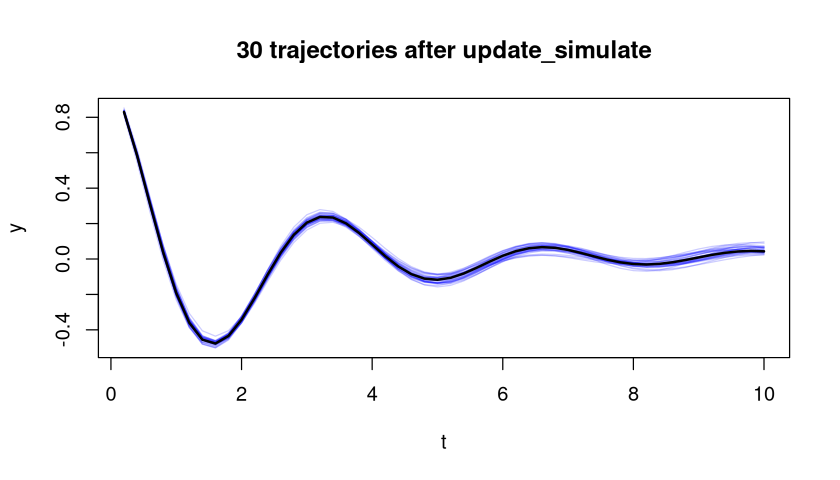

In [13]:
xs <- Xt[1:4, ]                                    # where the trajectories are drawn
Xu <- Xt[101:105, ]; Yu <- Yt[101:105, ]           # 5 new runs
sims <- simulate(pca, nsim = 2000, seed = 7, x = xs, will_update = TRUE)
cat("simulate:", dim(sims), "(m x q x nsim)\n")
sims_u <- update_simulate(pca, Yu, Xu)

update(pca, Yu, Xu, refit = FALSE)
pu <- predict(pca, xs)
emp <- apply(sims_u, c(1, 2), mean)
cat("max |empirical mean - updated mean| / max stdev:", round(max(abs(emp - pu$mean)) / max(pu$stdev), 4), "\n")

options(repr.plot.width = 7, repr.plot.height = 4)
matplot(t, sims_u[1, , 1:30], type = "l", lty = 1, col = rgb(0, 0, 1, 0.2), xlab = "t", ylab = "y",
        main = "30 trajectories after update_simulate")
lines(t, pu$mean[1, ], lwd = 2)

## 9. `save` and `load`

`save` writes the configuration, the data and the fitted state to a JSON file; `load` restores it exactly
(the generic `load` of each binding recognizes the file). The state of the last `simulate` is not saved: simulate
again before `update_simulate`.

In [14]:
f <- tempfile(fileext = ".json")
save(pca, f)                                       # the updated pca model of section 8
loaded <- load(f)                                  # or load.MultiOutputKriging(f)
cat(class(loaded), loaded$output_model(), loaded$nb_components(), "components\n")
cat("max |difference| of the predicted means:", max(abs(predict(pca, Xt)$mean - predict(loaded, Xt)$mean)), "\n")

MultiOutputKriging pca(0.999) 7 components


max |difference| of the predicted means: 0 


## 10. Summary

| Output model | Use it for | Hyperparameters |
|---|---|---|
| `"pca"` | many correlated outputs: curves, fields, q ≫ n possible | one Kriging per principal score |
| `"shared"` | outputs of similar regularity, marginal predictions | one θ, (β_j, σ_j²) per output |
| `"separable"` | a few correlated outputs, joint covariance or joint simulations | one θ, β_j per output, free Σ |
| `"separable(<kernel>)"` | outputs with coordinates and a stationary correlation along them, q ≫ n possible | one θ, β_j per output, σ², φ |

All four share the kernels, trends, `normalize` and optimizers of `Kriging`. Current limitations: isotopic design
only (no missing value in `Y`), no noise/nugget.

In [15]:
res <- rbind(pca = c(r_pca, t_pca), shared = c(r_shared, t_shared), independent = c(r_indep, t_indep),
             "separable(matern5_2)" = c(r_sk, t_sk))
colnames(res) <- c("RMSE/sd(Y)", "coverage", "fit time (s)")
round(res, 4)

,RMSE/sd(Y),coverage,fit time (s)
pca,0.0560,0.9475,0.071
shared,0.0462,0.9491,0.006
independent,0.0496,0.9477,0.243
separable(matern5_2),0.0511,0.9597,0.013
